# Deutsch Jotza Algorithm

The Deutsch-Jozsa algorithm is a classic in quantum computing. It’s one of the first examples proving that a quantum computer can solve a problem exponentially faster than a classical computer.

Specifically, it determines whether a "black box" function (an oracle) is constant (outputs 0 for all inputs, or 1 for all inputs) or balanced (outputs 0 for exactly half the inputs and 1 for the other half).

Here is the breakdown of the circuit design and how it works.

## The Circuit Blueprint

To handle an $n$-bit input, the circuit requires $n$ input qubits (initialized to $|0\rangle$) and 1 ancillary qubit (initialized to $|1\rangle$).

Here is the step-by-step layout of the circuit:

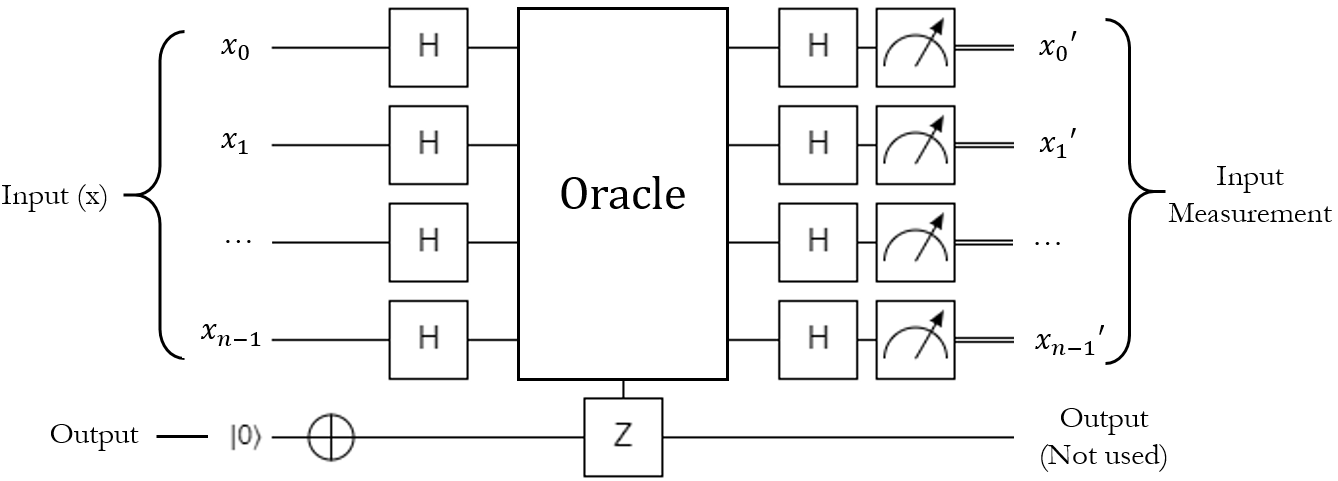

## Step-by-Step Circuit Breakdown

### 1. State Initialization

We start with $n$ qubits in the $|0\rangle$ state and the ancilla qubit in the $|1\rangle$ state.

$$\lvert \psi_0 \rangle = \lvert 0 \rangle^{\otimes n} \lvert 1 \rangle$$

### 2. Creating Superposition (The Hadamards)

We apply a Hadamard gate ($H$) to all qubits. For the input qubits, this puts them into an equal superposition of all possible $2^n$ states. For the ancilla, it transforms $|1\rangle$ into the $|-\rangle$ state.

$$\lvert \psi_1 \rangle = \sum_{x \in \{0,1\}^n} \frac{\lvert x \rangle}{\sqrt{2^n}} \left( \frac{\lvert 0 \rangle - \lvert 1 \rangle}{\sqrt{2}} \right)$$

### 3. The Oracle ($U_f$) and Phase Kickback

We pass the qubits through the oracle $U_f$, which evaluates the function $f(x)$. The oracle kicks the phase into the input register based on the output of $f(x)$:

$$\lvert \psi_2 \rangle = \sum_{x \in \{0,1\}^n} \frac{(-1)^{f(x)} \lvert x \rangle}{\sqrt{2^n}} \left( \frac{\lvert 0 \rangle - \lvert 1 \rangle}{\sqrt{2}} \right)$$

Notice how the ancilla state $|-\rangle$ remains unchanged, but its negative phase is "kicked back" to the input states where $f(x) = 1$.

### 4. Interference (The Second Wave of Hadamards)

We ignore the ancilla and apply Hadamard gates to the $n$ input qubits once more. This causes constructive or destructive interference. The state right before measurement looks like this:

$$\lvert \psi_3 \rangle = \sum_{y \in \{0,1\}^n} \sum_{x \in \{0,1\}^n} \frac{(-1)^{f(x) + x \cdot y}}{2^n} \lvert y \rangle$$

### 5. Measurement and Evaluation

We measure only the $n$ input qubits.

If the function is Constant: All the paths interfere destructively except for the $\lvert 0 \rangle^{\otimes n}$ state (the all-zeros state). You will measure all zeros with 100% probability.

If the function is Balanced: The paths for the $\lvert 0 \rangle^{\otimes n}$ state interfere destructively and perfectly cancel out. You will measure anything except all zeros.

## Why this is a Quantum Win

### Classical 

In the worst-case scenario, a classical computer would need to check $2^{n-1} + 1$ inputs to be absolutely sure if the function is balanced or constant.

### Quantum 

The Deutsch-Jozsa circuit evaluates the property with exactly 1 query to the oracle, no matter how large $n$ gets.

## Deutsch - Jotza Circuit Implementation

We first need to import necessary libraries for the creating and running the circuit.

In [1]:
from qiskit import QuantumCircuit, transpile
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator
import numpy as np

To implement Deutsch Jotza Algorithm, we need oracle. So let's create it.

In [2]:
def deustch_jozsa_oracle(n, oracle_type=None):
    """
    Generates a Deutsch-Jozsa oracle circuit.
    n: number of input qubits
    oracle_type: 'constant' or 'balanced'. If None, chooses randomly.
    """
    # Oracle circuit has n input qubits + 1 ancilla qubit (at index n)
    oracle_qc = QuantumCircuit(n + 1, name="Oracle")
    
    if oracle_type is None:
        oracle_type = np.random.choice(['constant', 'balanced'])
    #print(selected_type:=f"Generated a {oracle_type} oracle.")

    if oracle_type == 'constant':
        # A constant oracle either does nothing (outputs 0) 
        # or flips the ancilla qubit unconditionally (outputs 1)
        output = np.random.randint(2)
        if output == 1:
            oracle_qc.x(n) # Flip the ancilla qubit
            
    elif oracle_type == 'balanced':
        # A balanced oracle flips the ancilla based on a hidden bitstring.
        # We can simulate this using CX (CNOT) gates.
        b_str = np.random.randint(1, 2**n) # Random bitstring (not all zeros)
        
        # Wrap input qubits with X gates where the bitstring has a '0'
        # This ensures half the inputs trigger the CNOT gates
        for qubit in range(n):
            if not (b_str & (1 << qubit)):
                oracle_qc.x(qubit)
                
        # Apply controlled-NOT gates from inputs to the ancilla
        for qubit in range(n):
            oracle_qc.cx(qubit, n)
            
        # Uncompute the X gates to restore the input state
        for qubit in range(n):
            if not (b_str & (1 << qubit)):
                oracle_qc.x(qubit)
                
    return oracle_qc

Now, let's define the number of qubits and oracle type for which we need to create the circuit.

In [3]:
n = 4
oracle_type='balanced'

We need ancillary qubit at the end in this circuit. So we will define QuantumCircuit with n + 1 parameters.


In [4]:
dj_circuit = QuantumCircuit(n + 1, n)

# Initialize the ancilla qubit to |1>
dj_circuit.x(n)
dj_circuit.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=5, num_clbits=0, params=[]), qubits=(<Qubit register=(5, "q"), index=0>, <Qubit register=(5, "q"), index=1>, <Qubit register=(5, "q"), index=2>, <Qubit register=(5, "q"), index=3>, <Qubit register=(5, "q"), index=4>), clbits=())

Now, let's apply Hadamard gate to all the qubits, including ancilla qubit.

In [5]:
dj_circuit.h(range(n + 1))
dj_circuit.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=5, num_clbits=0, params=[]), qubits=(<Qubit register=(5, "q"), index=0>, <Qubit register=(5, "q"), index=1>, <Qubit register=(5, "q"), index=2>, <Qubit register=(5, "q"), index=3>, <Qubit register=(5, "q"), index=4>), clbits=())

We invoke Oracle and append it to our existing circuit.

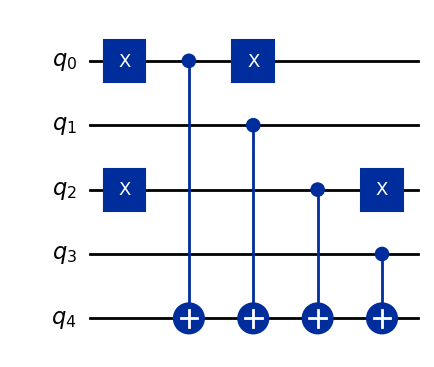

In [6]:
oracle = deustch_jozsa_oracle(n, oracle_type)
oracle.draw("mpl")

In [7]:
# We explicitly choose 'balanced' here to see it in action, or leave blank for random
oracle = deustch_jozsa_oracle(n, oracle_type='balanced')
dj_circuit.append(oracle.to_gate(), range(n + 1))
dj_circuit.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=5, num_clbits=0, params=[]), qubits=(<Qubit register=(5, "q"), index=0>, <Qubit register=(5, "q"), index=1>, <Qubit register=(5, "q"), index=2>, <Qubit register=(5, "q"), index=3>, <Qubit register=(5, "q"), index=4>), clbits=())

Let's apply Hadamard gate again to all the input qubits and measure the qubits.

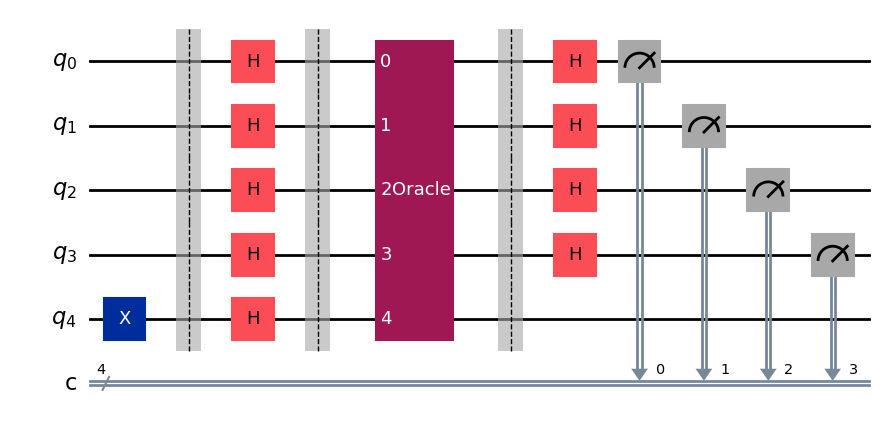

In [8]:
dj_circuit.h(range(n))

# Measure the input qubits
dj_circuit.measure(range(n), range(n))

dj_circuit.draw(output= "mpl")

We now have complete circuit, let's run this on simulator.

In [9]:
simulator = AerSimulator()
qc = transpile(dj_circuit, simulator)
result = simulator.run(qc, shots=1).result()
counts = result.get_counts()

## Reading Results

If the result printed Generated a constant oracle, your final measurement result will always yield in all the zeros.

If the result printed Generated a balanced oracle, your final measurement will be anything except all zeros.

In [10]:
print(f"Measurement result: {counts}")

Measurement result: {'1111': 1}


As we can see, result is not 0000 in our case, this means we don't have constant oracle. We have balanced oracle.

This matches with the oracle type we defined earlier. 